# 🏓 Deep Q-Learning: Pong Deterministic

This notebook utilizes an Object-Oriented implementation of a Deep Q-Network (DQN) to solve the Atari Pong environment. We will run ablations on batch sizes and target update rates, and reflect on the core Multi-Armed Bandit principles underlying reinforcement learning.

In [3]:
import matplotlib.pyplot as plt
from pong_dqn_oop import PongTrainer, DEVICE

print(f"Using compute device: {DEVICE}")

Using compute device: cuda


## 1. Running the Ablation Study
We will initialize multiple instances of our `PongTrainer` class to test the combinations required by the assignment.

In [4]:
episodes_to_run = 300 # Number of episodes to train for each configuration

# 1. Default Parameters (Batch=8, Update=10)
trainer_default = PongTrainer(batch_size=8, target_update_rate=10)
steps_b8, scores_b8, avg_b8 = trainer_default.train(episodes=episodes_to_run)

# 2. Modified Batch Size (Batch=16, Update=10)
trainer_batch16 = PongTrainer(batch_size=16, target_update_rate=10)
steps_b16, scores_b16, avg_b16 = trainer_batch16.train(episodes=episodes_to_run)

# 3. Modified Update Rate (Batch=8, Update=3)
trainer_update3 = PongTrainer(batch_size=8, target_update_rate=3)
steps_t3, scores_t3, avg_t3 = trainer_update3.train(episodes=episodes_to_run)

2026-03-29 22:42:42 - Starting training loop: 300 episodes | Batch: 8 | Target Update: 10
INFO:PongTrainer_8_10:Starting training loop: 300 episodes | Batch: 8 | Target Update: 10
2026-03-29 22:42:51 - Episode: 1, Score: -20.0, Avg(Last 5): -20.00, Epsilon: 0.995
INFO:PongTrainer_8_10:Episode: 1, Score: -20.0, Avg(Last 5): -20.00, Epsilon: 0.995
2026-03-29 22:42:58 - Episode: 2, Score: -21.0, Avg(Last 5): -20.50, Epsilon: 0.990
INFO:PongTrainer_8_10:Episode: 2, Score: -21.0, Avg(Last 5): -20.50, Epsilon: 0.990
2026-03-29 22:43:07 - Episode: 3, Score: -20.0, Avg(Last 5): -20.33, Epsilon: 0.985
INFO:PongTrainer_8_10:Episode: 3, Score: -20.0, Avg(Last 5): -20.33, Epsilon: 0.985
2026-03-29 22:43:14 - Episode: 4, Score: -21.0, Avg(Last 5): -20.50, Epsilon: 0.980
INFO:PongTrainer_8_10:Episode: 4, Score: -21.0, Avg(Last 5): -20.50, Epsilon: 0.980
2026-03-29 22:43:22 - Episode: 5, Score: -21.0, Avg(Last 5): -20.60, Epsilon: 0.975
INFO:PongTrainer_8_10:Episode: 5, Score: -21.0, Avg(Last 5): -20

## 2. Visualizing the Results
Let's plot the comparative metrics side-by-side as requested.

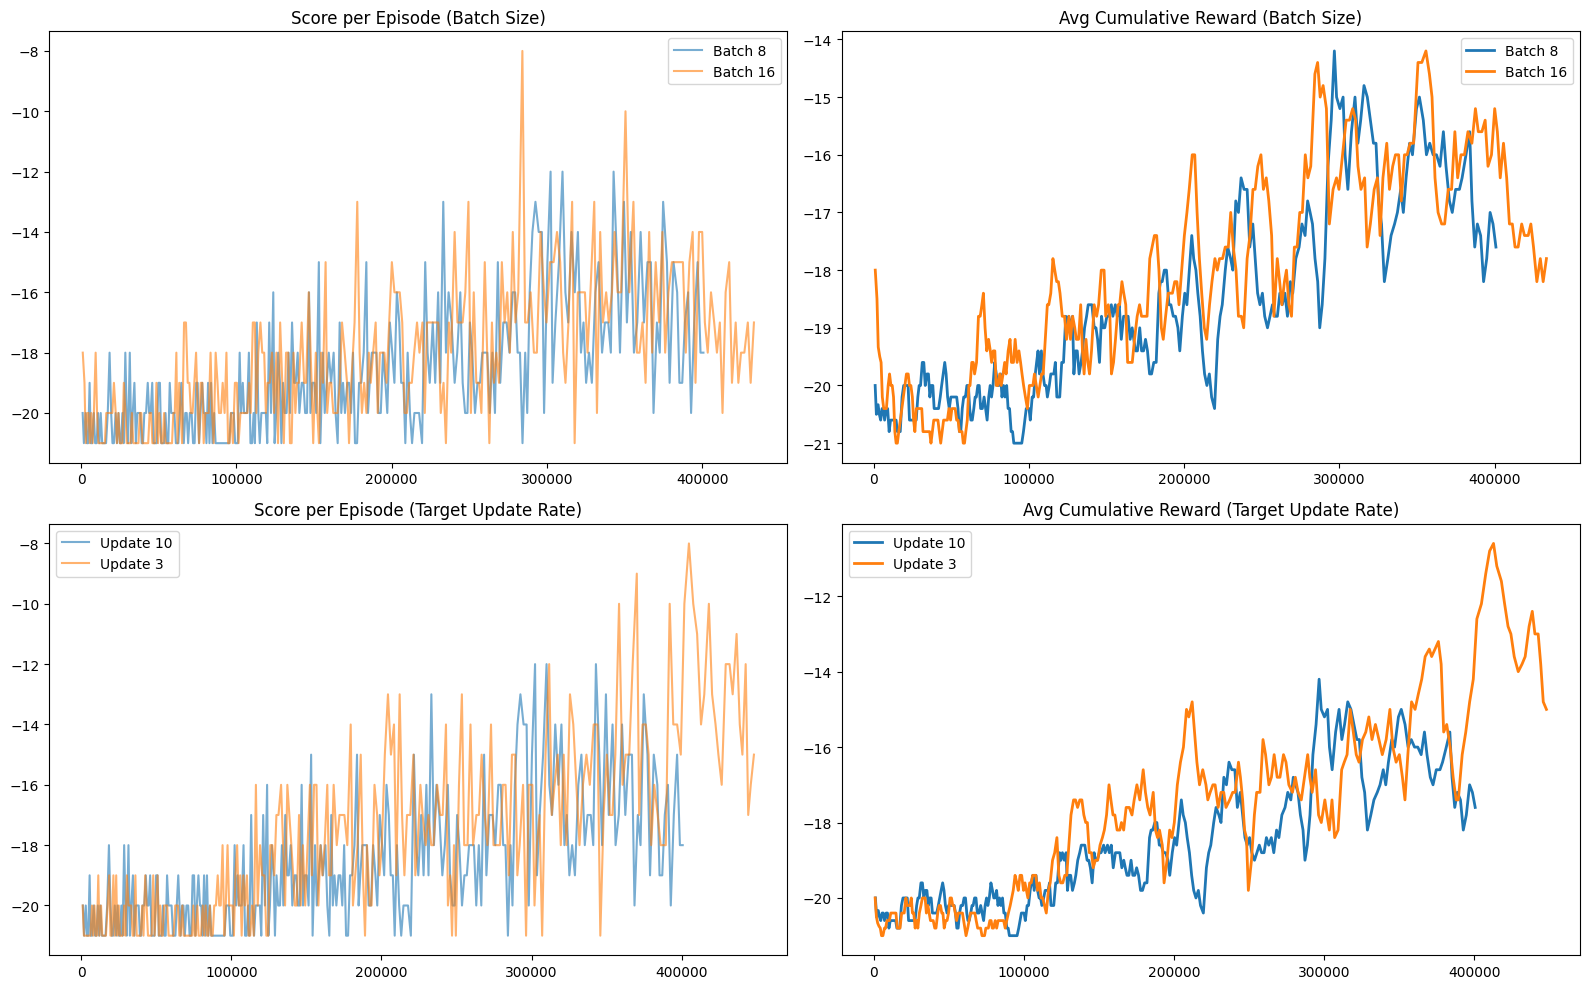

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Batch Size Ablation
axs[0, 0].plot(steps_b8, scores_b8, label='Batch 8', alpha=0.6)
axs[0, 0].plot(steps_b16, scores_b16, label='Batch 16', alpha=0.6)
axs[0, 0].set_title("Score per Episode (Batch Size)")
axs[0, 0].legend()

axs[0, 1].plot(steps_b8, avg_b8, label='Batch 8', linewidth=2)
axs[0, 1].plot(steps_b16, avg_b16, label='Batch 16', linewidth=2)
axs[0, 1].set_title("Avg Cumulative Reward (Batch Size)")
axs[0, 1].legend()

# Target Update Rate Ablation
axs[1, 0].plot(steps_b8, scores_b8, label='Update 10', alpha=0.6)
axs[1, 0].plot(steps_t3, scores_t3, label='Update 3', alpha=0.6)
axs[1, 0].set_title("Score per Episode (Target Update Rate)")
axs[1, 0].legend()

axs[1, 1].plot(steps_b8, avg_b8, label='Update 10', linewidth=2)
axs[1, 1].plot(steps_t3, avg_t3, label='Update 3', linewidth=2)
axs[1, 1].set_title("Avg Cumulative Reward (Target Update Rate)")
axs[1, 1].legend()

plt.tight_layout()

plt.savefig("outputs/batch_size_ablation.png")
plt.savefig("outputs/target_update_ablation.png")

plt.show()

## 3. Reflections: Bridging Multi-Armed Bandits & Deep Q-Learning

### The Exploration-Exploitation Trade-off (Why $\epsilon$ matters)
In reinforcement learning, if an agent acts purely greedily ($\epsilon = 0.0$) from the beginning, it will immediately exploit the very first sub-optimal pattern it discovers, permanently ignoring strategies that might yield massive rewards. Conversely, if it constantly explores ($\epsilon = 0.9$), it wastes computational cycles trying random moves long after it has mapped the optimal path.

In our DQN implementation, we manage this trade-off using a **decaying $\epsilon$-greedy strategy**. The agent begins with $\epsilon = 1.0$, exploring completely randomly to understand the physics of the Pong ball. As episodes pass, $\epsilon$ decays by `0.995`, smoothly transitioning the agent into an exploitation phase where it relies on its heavily trained neural network to actually win the game, hitting a minimum floor of `0.05` to ensure it occasionally tests new edge cases.

### Non-Stationarity and the Constant-$\alpha$ Parallels
In a standard stationary Bandit problem, a $1/N$ step size is ideal because the true mean never changes. However, in a **Non-Stationary environment**, older estimates become useless as the environment drifts. A **constant-$\alpha$** (Exponential Moving Average) fixes this by permanently assigning heavy weight to the most recent rewards, allowing the agent to continuously overwrite outdated beliefs.

**How this applies to DQN:** Deep Q-Learning is inherently non-stationary. Because the neural network is constantly updating, the Q-value targets derived from the Bellman Equation are constantly shifting targets. If we used a $1/N$ learning rate, the network would eventually freeze and fail to learn. Instead, we use the `Adam` optimizer with a fixed learning rate of `0.0001`. This acts exactly like a **constant-$\alpha$**, ensuring the neural network remains agile enough to adapt to its own shifting estimations.

## 4. Saving and Playing
Because we used an OOP design, we can easily save our best model and watch it play visually without re-training!

In [6]:
# Save the weights of our default trainer
trainer_default.save("pong_dqn_best_model.pth")

# Launch the game window
trainer_default.play(episodes=3)

--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f4be' in position 22: character maps to <undefined>
Call stack:
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Assignment 3\.venv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Assignment 3\.venv\lib\site-package